In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [2]:
np.random.seed(42)

temperature = np.random.uniform(low=20, high=40, size=100)

sales = (temperature * 12.5) + np.random.normal(loc=0, scale=25, size=100) + 50

df = pd.DataFrame({'Temperature_C': temperature, 'Sales_Units': sales})

#df.head()
print(df)

    Temperature_C  Sales_Units
0       27.490802   395.811206
1       39.014286   530.203393
2       34.639879   485.292505
3       31.973170   399.975398
4       23.120373   333.512863
..            ...          ...
95      29.875912   403.053642
96      30.454657   428.755665
97      28.550820   415.414054
98      20.508383   313.272052
99      22.157829   347.652438

[100 rows x 2 columns]


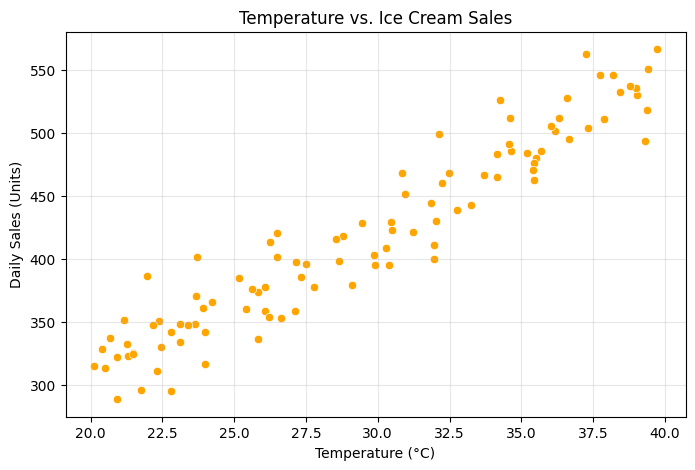

In [3]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temperature_C', y='Sales_Units', data=df, color='orange')
plt.title('Temperature vs. Ice Cream Sales')
plt.xlabel('Temperature (°C)')
plt.ylabel('Daily Sales (Units)')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
X = df[['Temperature_C']] # 2D Array
y = df['Sales_Units']     # 1D Array

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Size: {X_train.shape}")
print(f"Test Data Size: {X_test.shape}")

Training Data Size: (80, 1)
Test Data Size: (20, 1)


In [5]:
model = LinearRegression()

model.fit(X_train, y_train)
# Sales = b0 + (b1 x Heat) 
# Sales = 63.61 + (12 x Heat)

print("Model training completed.")
print(f"Model intercept (b0): {model.intercept_:.2f}")
print(f"Model coefficient (b1): {model.coef_[0]:.2f}")

Model training completed.
Model intercept (b0): 63.61
Model coefficient (b1): 12.00


In [6]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(comparison.head())

# success metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}") # Average error in units
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared (R2 Score): {r2:.2f}") # How well the model explains the variance in the data (closer to 1 is better)

       Actual   Predicted
0  332.303428  318.824688
1  511.119946  518.301137
2  462.137425  488.885463
3  442.895885  462.555777
4  384.470794  365.671277

--- Model Performance ---
Mean Absolute Error (MAE): 14.78
Root Mean Squared Error (RMSE): 20.21
R-Squared (R2 Score): 0.93


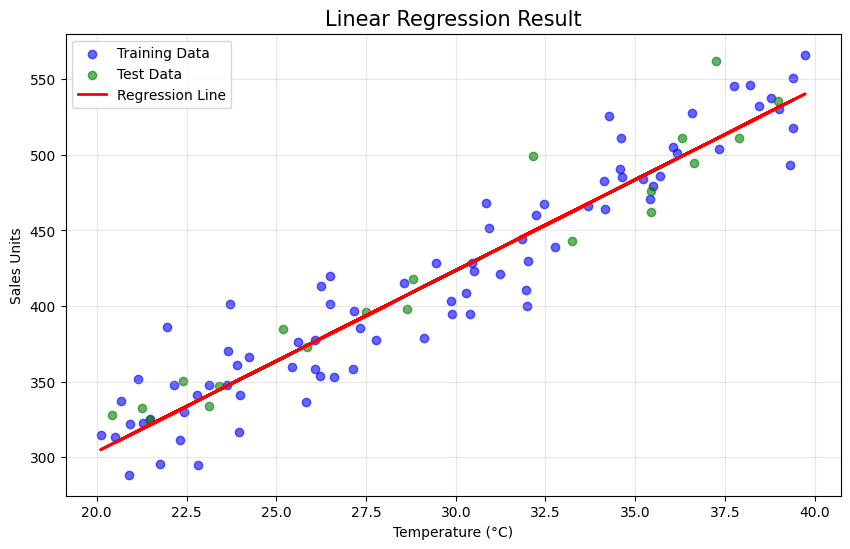

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)
plt.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.6)
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression Line')

plt.title('Linear Regression Result', fontsize=15)
plt.xlabel('Temperature (°C)')
plt.ylabel('Sales Units')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
example_temperature = [[0]] 
predicted_sales = model.predict(example_temperature)

print(f"When the temperature is {example_temperature[0][0]} degrees, the predicted ice cream sales are: {int(predicted_sales[0])} units.")

When the temperature is 0 degrees, the predicted ice cream sales are: 63 units.
